### Shape steering on natural images

#### Load questions and annotations

In [1]:
import os
import json
import zipfile
import urllib.request

vqa_dir = "vqa_dataset"
os.makedirs(vqa_dir, exist_ok=True)

questions_url = "https://cvmlp.s3.amazonaws.com/vqa/mscoco/vqa/v2_Questions_Train_mscoco.zip"
annotations_url = "https://cvmlp.s3.amazonaws.com/vqa/mscoco/vqa/v2_Annotations_Train_mscoco.zip"

questions_zip = os.path.join(vqa_dir, "questions.zip")
annotations_zip = os.path.join(vqa_dir, "annotations.zip")

questions_file = os.path.join(vqa_dir, "v2_OpenEnded_mscoco_train2014_questions.json")
annotations_file = os.path.join(vqa_dir, "v2_mscoco_train2014_annotations.json")

# Download zip files only if missing
if not os.path.exists(questions_zip):
  urllib.request.urlretrieve(questions_url, questions_zip)
if not os.path.exists(annotations_zip):
  urllib.request.urlretrieve(annotations_url, annotations_zip)

# Extract only if JSON files are missing
if not os.path.exists(questions_file):
  with zipfile.ZipFile(questions_zip, "r") as zip_ref:
    zip_ref.extractall(vqa_dir)

if not os.path.exists(annotations_file):
  with zipfile.ZipFile(annotations_zip, "r") as zip_ref:
    zip_ref.extractall(vqa_dir)

# Load JSON files
with open(questions_file, "r") as f:
  questions = json.load(f)

with open(annotations_file, "r") as f:
  annotations = json.load(f)

print(f"Loaded {len(questions['questions'])} questions")
print(f"Loaded {len(annotations['annotations'])} annotations")

Loaded 443757 questions
Loaded 443757 annotations


In [2]:
questions['questions'][0]

{'image_id': 458752,
 'question': 'What is this photo taken looking through?',
 'question_id': 458752000}

In [3]:
annotations['annotations'][0]

{'question_type': 'what is this',
 'multiple_choice_answer': 'net',
 'answers': [{'answer': 'net', 'answer_confidence': 'maybe', 'answer_id': 1},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 2},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 3},
  {'answer': 'netting', 'answer_confidence': 'yes', 'answer_id': 4},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 5},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 6},
  {'answer': 'mesh', 'answer_confidence': 'maybe', 'answer_id': 7},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 8},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 9},
  {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 10}],
 'image_id': 458752,
 'answer_type': 'other',
 'question_id': 458752000}

In [4]:
# Filter questions containing "What shape is"
filtered_questions = [q for q in questions['questions'] if "What shape is" in q['question']]

# Get the image IDs of filtered questions
filtered_image_ids = {q['question_id'] for q in filtered_questions}

# Filter annotations that match the image IDs
filtered_annotations = [a for a in annotations['annotations'] if a['question_id'] in filtered_image_ids]

print(f"Found {len(filtered_questions)} questions containing 'What shape is'")
print(f"Found {len(filtered_annotations)} corresponding annotations")

Found 743 questions containing 'What shape is'
Found 743 corresponding annotations


In [5]:
# Define the target shapes
target_shapes = {'square', 'triangle', 'circle', 'pentagon', 'star', 'heart'}

# Filter annotations that have one of the target shapes as the answer
shape_filtered_annotations = [
  a for a in filtered_annotations 
  if a['multiple_choice_answer'].lower() in target_shapes
]

# Get the question IDs of filtered annotations
shape_filtered_question_ids = {a['question_id'] for a in shape_filtered_annotations}

# Filter questions that match the shape-filtered annotations
shape_filtered_questions = [
  q for q in filtered_questions 
  if q['question_id'] in shape_filtered_question_ids
]

print(f"Found {len(shape_filtered_annotations)} annotations with target shapes")
print(f"Found {len(shape_filtered_questions)} corresponding questions")

Found 297 annotations with target shapes
Found 297 corresponding questions


In [6]:
import matplotlib.pyplot as plt

def inspect_dataset(index):
  """
  Inspect a dataset element by index, showing question, image, and answer.
  
  Args:
    index: Index in shape_filtered_questions
  """
  if index < 0 or index >= len(shape_filtered_questions):
    print(f"Index {index} out of range. Dataset has {len(shape_filtered_questions)} samples.")
    return
  
  # Get question
  question = shape_filtered_questions[index]
  question_id = question['question_id']
  image_id = question['image_id']
  
  print(f"Index: {index}")
  print(f"Question: {question['question']}")
  print(f"Question ID: {question_id}")
  print(f"Image ID: {image_id}\n")
  print(f"url: http://images.cocodataset.org/train2014/COCO_train2014_{image_id:012d}.jpg\n")
  
  # Get ground truth answer
  gt_annotation = next((a for a in shape_filtered_annotations if a['question_id'] == question_id), None)
  if gt_annotation:
    print(f"Ground Truth Answer: {gt_annotation['multiple_choice_answer']}\n")
  
  # Download and display image
  img_url = f"http://images.cocodataset.org/train2014/COCO_train2014_{image_id:012d}.jpg"
  img_path = f"./temp_inspect_img_{image_id}.jpg"
  try:
    urllib.request.urlretrieve(img_url, img_path)
    img = plt.imread(img_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Q: {question['question']}\nA: {gt_annotation['multiple_choice_answer'] if gt_annotation else 'N/A'}")
    plt.tight_layout()
    plt.show()
    os.remove(img_path)
  except Exception as e:
    print(f"Error loading image: {e}")

# Example usage: inspect_dataset(0)

In [7]:
[(i,a) for i,a in enumerate(shape_filtered_annotations) if a['multiple_choice_answer'].lower() == 'pentagon']

[(54,
  {'answer_type': 'other',
   'multiple_choice_answer': 'pentagon',
   'answers': [{'answer': 'hexagon',
     'answer_confidence': 'yes',
     'answer_id': 1},
    {'answer': "i don't know", 'answer_confidence': 'yes', 'answer_id': 2},
    {'answer': 'triangle', 'answer_confidence': 'maybe', 'answer_id': 3},
    {'answer': 'pentagon', 'answer_confidence': 'yes', 'answer_id': 4},
    {'answer': 'pentagon', 'answer_confidence': 'yes', 'answer_id': 5},
    {'answer': 'pentagon', 'answer_confidence': 'yes', 'answer_id': 6},
    {'answer': 'pentagon', 'answer_confidence': 'yes', 'answer_id': 7},
    {'answer': 'square', 'answer_confidence': 'maybe', 'answer_id': 8},
    {'answer': 'triangle', 'answer_confidence': 'yes', 'answer_id': 9},
    {'answer': 'triangle', 'answer_confidence': 'yes', 'answer_id': 10}],
   'image_id': 48756,
   'question_type': 'what',
   'question_id': 48756000})]

Index: 1
Question: What shape is the froth?
Question ID: 605001
Image ID: 605

url: http://images.cocodataset.org/train2014/COCO_train2014_000000000605.jpg

Ground Truth Answer: heart



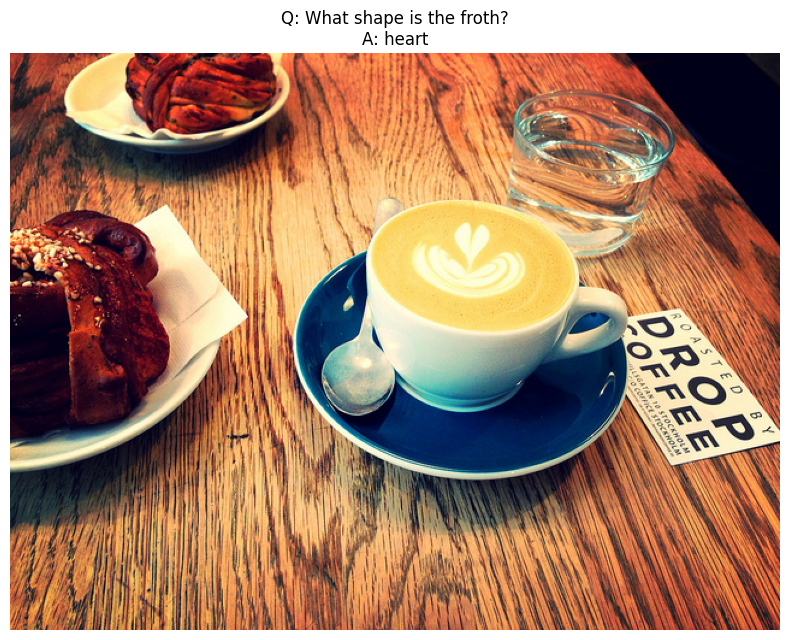

In [8]:
inspect_dataset(1)

In [9]:
import pandas as pd
pd.DataFrame(shape_filtered_annotations).value_counts('multiple_choice_answer')

multiple_choice_answer
square      126
circle       75
triangle     47
heart        28
star         20
pentagon      1
Name: count, dtype: int64

#### Import and utilities

In [10]:
model_name = 'gemma' #'qwen', 'intern' or 'gemma'

In [11]:
import torch
import matplotlib.pyplot as plt, seaborn as sns
import pandas as pd
import hydra
from tqdm import tqdm
import numpy as np
import pickle, os
from transformers.utils import ModelOutput

import sys
sys.path.append('./src')

In [12]:
from transformers.utils import logging
logging.set_verbosity_error() 

In [13]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize("config")
cfg = hydra.compose("activations_gen", overrides=[dict(qwen='+experiment=bal_qwen7b',
                                                       intern='+experiment=bal_internvl8b',
                                                       intern3='+experiment=bal_internvl3_8b',
                                                       gemma='+experiment=bal_gemma12b')[model_name],
                                                  ])
dataset_name = 'real_dataset_shapes'

/tmp/ipykernel_757286/1219719268.py:2: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize("config")


In [14]:
colors=cfg.dataset.COLORS.copy()
shapes=cfg.dataset.SHAPES.copy()

In [15]:
def _generate_proj_hook(layer_name : str,
                        prototypes: list = None):
  '''Generates an hook that performs 'projection patching', steering from prototypes[0]
  into prototypes[1].
  '''

  def proj_hook(model,input,output):
    if isinstance(output, tuple):
      #output = output[0] #usually other indexes are attentions
      tochange = output[0]['last_hidden_state']# without .cpu (even with .clone) raises error
    elif isinstance(output,torch.Tensor):
      tochange = output
    elif isinstance(output, ModelOutput):
      tochange = output['last_hidden_state'] # without .cpu (even with .clone) raises error
    # 'last_hidden_state' should be model-agnostic, but im not sure
    else:
      raise Exception(f"Hook in layer {layer_name}: output type unknown, {type(output)}")

    # print(tochange.shape)
    initshape = tochange.shape
    inittype = tochange.dtype
    tochangecloned = tochange.squeeze().to(torch.float)
    #print(initshape,tochangecloned.shape)
    if prototypes is None:
      raise Error
    del_prot = prototypes[0]
    ins_prot = prototypes[1]
    if len(tochangecloned.shape) == 3: #internvl splits one big image in subpictures, like 3×256×4k
      tochangecloned=tochangecloned.flatten(end_dim=1)
    
    for targettoken in range(tochangecloned.shape[0]): #make target appear
      target_proj_module = (tochangecloned[targettoken,:]@del_prot)
      tochangecloned[targettoken,:] = tochangecloned[targettoken,:]-target_proj_module*del_prot+target_proj_module*ins_prot
    
    tochange.copy_(tochangecloned.reshape(initshape).to(inittype))
    return output
  return proj_hook

#### Load model

In [16]:
model = hydra.utils.instantiate(cfg.model)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [17]:
from transformers.utils import ModelOutput

In [18]:
from transformers import GenerationConfig
if "InternVL3" in cfg.model.model_name:
      generation_kwargs = { 
            "max_new_tokens": 8, 
            "do_sample": False, #avoid sampling outputs (greedy choice)
            "return_dict_in_generate": True,  #outputs is a dictionary, following args specify its contents
            "output_attentions": False, # Passed to all submodels, needed to use hooks
            "output_hidden_states": False,
            "output_logits": True,  # These are handy
            "output_scores": False,
            "pad_token_id": 151645,
          }
      def getstring(model,output,input_len):
            return model.processor.decode(output['sequences'][0][input_len:])
elif 'Intern' in cfg.model.model_name:
    generation_kwargs = dict(generation_config=GenerationConfig( 
    max_new_tokens= 8, 
    do_sample= False, #avoid sampling outputs (greedy choice)
    return_dict_in_generate= True,  #outputs is a dictionary, following args specify its contents
    output_attentions= False, # Passed to all submodels, needed to use hooks
    output_hidden_states= False,
    output_logits= True,  # These are handy
    output_scores= False,
    eos_token_id=92542
    ) )
    # I'll move this to the model class sooner or later
    def getstring(model,output,input_len):
      return model.processor.decode(output['sequences'][0])
else:
    generation_kwargs = { 
      "max_new_tokens": 8,
      "do_sample": False, #avoid sampling outputs (greedy choice)
      "return_dict_in_generate": True,  #outputs is a dictionary, following args specify its contents
      "output_attentions": False, # Passed to all submodels, needed to use hooks
      "output_hidden_states": False,
      "output_logits": True,  # These are handy
      "output_scores": False,
    }
    def getstring(model,output,input_len):
        return model.processor.decode(output['sequences'][0][input_len:])

#### Generate original (no steering) outputs

We let the model do whatever it wants with the resizing and tokenization of the image, but apply steering indiscriminately to all embedding tokens.

In [ ]:
probs = []
probs_ids = []
outs = []
logits = []
ground_truth = []
top_tokens = []  # Store top 20 token strings

for q_idx, question in tqdm(enumerate(shape_filtered_questions)):
  question_id = question['question_id']
  image_id = question['image_id']
  
  # Get ground truth answer
  gt_annotation = next((a for a in shape_filtered_annotations if a['question_id'] == question_id), None)
  if gt_annotation is None:
    continue
  
  gt_answer = gt_annotation['multiple_choice_answer'].lower()
  ground_truth.append(gt_answer)
  
  # Download image from COCO dataset
  img_url = f"http://images.cocodataset.org/train2014/COCO_train2014_{image_id:012d}.jpg"
  img_path = f"./temp_img_{image_id}.jpg"
  try:
    urllib.request.urlretrieve(img_url, img_path)
  except:
    ground_truth.pop()
    continue
  
  # Generate model input and get prediction
  prompt = question['question']+' Answer in one word.'  # Add instruction for clearer answers
  model_input = model.get_inputs(img_path, prompt)
  
  with torch.inference_mode():
    generation_output = model.model.generate(**model_input, **generation_kwargs)
  
  input_len = model_input["input_ids"].shape[-1]
  str_out = getstring(model, generation_output, input_len)
  outputsm = torch.nn.functional.softmax(generation_output['logits'][0], dim=-1)
  top_probs, top_ids = outputsm[0].topk(20)  # Get top 20 instead of 10
  logits_out = generation_output['logits'][0][0, top_ids].cpu()
  
  # Convert token IDs to token strings
  tokens_str = [model.processor.decode([tid.item()]) for tid in top_ids.cpu()]
  
  probs.append(top_probs.cpu())
  probs_ids.append(top_ids.cpu())
  outs.append(str_out)
  logits.append(logits_out)
  top_tokens.append(tokens_str)
  
  # Clean up temp image
  os.remove(img_path)

# Create results dataframe
results_df = pd.DataFrame({
  'model_output': outs,
  'ground_truth': ground_truth,
  'top_20_tokens': top_tokens,
  'top_20_probs': probs,
  'match': [out.lower().strip() == gt.lower().strip() for out, gt in zip(outs, ground_truth)],
  'match_substring': [gt.lower().strip() in out.lower().strip() for out, gt in zip(outs, ground_truth)]
})

print(f"Accuracy: {results_df['match'].sum() / len(results_df) * 100:.2f}%")
print(results_df)

In [19]:
# Extract unique output words (lowercase, removing special tokens)
unique_outputs = set()

for output in results_df['model_output']:
  # Remove special tokens and convert to lowercase
  cleaned = output.replace('<|im_end|>', '').strip().lower()
  if cleaned:
    unique_outputs.add(cleaned)

# Convert to sorted list for better readability
unique_outputs_list = sorted(list(unique_outputs))
print(f"Total unique outputs: {len(unique_outputs_list)}")
print(unique_outputs_list)

Total unique outputs: 65
['a-frame<end_of_turn>', 'arc<end_of_turn>', 'arched<end_of_turn>', 'arrow<end_of_turn>', 'bottle<end_of_turn>', 'brick<end_of_turn>', 'cat<end_of_turn>', 'checkered<end_of_turn>', 'circle.<end_of_turn>', 'circle<end_of_turn>', 'circles<end_of_turn>', 'circular<end_of_turn>', 'cone<end_of_turn>', 'crescent<end_of_turn>', 'curve<end_of_turn>', 'curved<end_of_turn>', 'cylindrical<end_of_turn>', 'diamond<end_of_turn>', 'disc<end_of_turn>', 'dome.<end_of_turn>', 'dragon<end_of_turn>', 'elongated<end_of_turn>', 'feathery<end_of_turn>', 'floral<end_of_turn>', 'gable<end_of_turn>', 'geometric<end_of_turn>', 'gothic<end_of_turn>', 'heart<end_of_turn>', 'hearts<end_of_turn>', 'irregular<end_of_turn>', 'leaf<end_of_turn>', 'line<end_of_turn>', 'loop.<end_of_turn>', 'octagon<end_of_turn>', 'oval.<end_of_turn>', 'oval<end_of_turn>', 'pear<end_of_turn>', 'pentagon<end_of_turn>', 'polygons<end_of_turn>', 'post<end_of_turn>', 'pyramid<end_of_turn>', 'rectangle<end_of_turn>', 

In [20]:
import os
import json

# Create output subfolder
output_dir = os.path.join('outputs', 'vqa_results')
os.makedirs(output_dir, exist_ok=True)

# Save results dataframe to CSV
results_csv_path = os.path.join(output_dir, f'results_{model_name}.csv')
results_df.to_csv(results_csv_path, index=False)

# Save unique outputs to JSON
unique_outputs_path = os.path.join(output_dir, f'unique_outputs_{model_name}.json')
with open(unique_outputs_path, 'w') as f:
  json.dump(unique_outputs_list, f, indent=2)

# Save summary statistics to JSON
summary = {
  'total_samples': len(results_df),
  'accuracy': float(results_df['match'].sum() / len(results_df) * 100),
  'num_unique_outputs': len(unique_outputs_list),
  'unique_outputs': unique_outputs_list
}
summary_path = os.path.join(output_dir, f'summary_{model_name}.json')
with open(summary_path, 'w') as f:
  json.dump(summary, f, indent=2)

print(f"Results saved to {output_dir}")
print(f"  - results_{model_name}.csv: {results_csv_path}")
print(f"  - unique_outputs_{model_name}.json: {unique_outputs_path}")
print(f"  - summary_{model_name}.json: {summary_path}")

Results saved to outputs/vqa_results
  - results_gemma.csv: outputs/vqa_results/results_gemma.csv
  - unique_outputs_gemma.json: outputs/vqa_results/unique_outputs_gemma.json
  - summary_gemma.json: outputs/vqa_results/summary_gemma.json


#### Steering

In [ ]:
handles['mmp'].remove() # to remove handles and run model without steering

In [19]:
template_label = 'avgprobe'
## 'probe'
## 'probepca'
## 'centroid'
## 'avgprobe'
col_templates = torch.load(f'./outputs/{cfg.model.model_name}/color_cv_{template_label}.pt')[:6]
sha_templates = torch.load(f'./outputs/{cfg.model.model_name}/color_cv_{template_label}.pt')[6:]
sha_templates.shape

torch.Size([6, 3840])

In [20]:
# load pre-computed no-steering results
output_dir = os.path.join('outputs', 'vqa_results')
unique_outputs_path = os.path.join(output_dir, f'unique_outputs_{model_name}.json')
summary_path = os.path.join(output_dir, f'summary_{model_name}.json')
# Load previously saved results
results_df = pd.read_csv(os.path.join(output_dir, f'results_{model_name}.csv'))

with open(unique_outputs_path, 'r') as f:
  unique_outputs_list = json.load(f)

with open(summary_path, 'r') as f:
  summary = json.load(f)

print(f"Loaded {len(results_df)} results")
print(f"Loaded {len(unique_outputs_list)} unique outputs")
#print(f"Baseline accuracy: {summary['accuracy']:.2f}%")

Loaded 297 results
Loaded 65 unique outputs


In [21]:
results_df['match_substring'] = results_df.apply(
  lambda row: row['ground_truth'].lower().strip() in row['model_output'].lower().strip(),
  axis=1
)
results_df['match_substring'].value_counts()

match_substring
False    186
True     111
Name: count, dtype: int64

In [22]:
matched_out = results_df[results_df['match_substring'] == True]['model_output']
cleaned = matched_out.str.replace(r'\.', '', regex=True).str.lower().str.strip()

unique_values = cleaned.unique()
print("unique count:", len(unique_values))
print("unique values:", sorted(unique_values))

unique count: 10
unique values: ['circle<end_of_turn>', 'circles<end_of_turn>', 'heart<end_of_turn>', 'hearts<end_of_turn>', 'pentagon<end_of_turn>', 'square<end_of_turn>', 'squares<end_of_turn>', 'star<end_of_turn>', 'triangle<end_of_turn>', 'triangles<end_of_turn>']


In [23]:
prototypes = [] #this list will contain [conc vec to delete, conc vec to hallucinate]
handles  = model.register_hooks(hook_generator = _generate_proj_hook,
                        hook_layers = {'mmp': cfg.model.probe_layers['mmp']},
                        hook_generator_kwargs={
                                              'prototypes': prototypes,
                                              })

In [24]:
coldict = dict()
for i in range(6):
  coldict[colors[i]]=i

shadict = dict()
for i in range(6):
  shadict[shapes[i]]=i

In [25]:
probs_st = []
probs_ids_st = []
outs_st = []
logits_st = []
shapes_st = []
ids_st = []
image_ids_st = []  # Add list for image IDs
top_tokens_st = []  # Add this for top 20 tokens

# Filter to only correctly answered questions
correct_results = results_df[results_df['match_substring'] == True]

with tqdm(total=len(shapes)*len(correct_results)) as pbar:
  for end_shape in shapes:
    for idx, row in correct_results.iterrows():
      gt_answer = row['ground_truth']
      
      if gt_answer != end_shape:
        prototypes.clear()
        prototypes.append(sha_templates[shadict[gt_answer]].cuda())
        prototypes.append(sha_templates[shadict[end_shape]].cuda())
        
        q_idx = idx
        question = shape_filtered_questions[q_idx]
        question_id = question['question_id']
        image_id = question['image_id']
        
        img_path = f"./temp_img_{image_id}.jpg"
        img_url = f"http://images.cocodataset.org/train2014/COCO_train2014_{image_id:012d}.jpg"
        
        try:
          urllib.request.urlretrieve(img_url, img_path)
        except:
          pbar.update()
          continue
        
        prompt = question['question'] + ' Answer in one word.'
        model_input = model.get_inputs(img_path, prompt)
        
        with torch.inference_mode():
          generation_output = model.model.generate(**model_input, **generation_kwargs)
        
        input_len = model_input["input_ids"].shape[-1]
        str_out = getstring(model, generation_output, input_len)
        outputsm = torch.nn.functional.softmax(generation_output['logits'][0], dim=-1)
        top_probs, top_ids = outputsm[0].topk(20)
        logits_out = generation_output['logits'][0][0, top_ids].cpu()
        
        # Convert token IDs to token strings for top 20
        tokens_str = [model.processor.decode([tid.item()]) for tid in top_ids.cpu()]
        
        probs_st.append(top_probs.cpu())
        probs_ids_st.append(top_ids.cpu())
        outs_st.append(str_out)
        logits_st.append(logits_out)
        shapes_st.append([gt_answer, end_shape])
        ids_st.append(question_id)
        image_ids_st.append(image_id)  # Append image ID
        top_tokens_st.append(tokens_str)
        
        os.remove(img_path)
      
      pbar.update()

# Create results dataframe for steered outputs
steered_results_df = pd.DataFrame({
  'model_output': outs_st,
  'original_shape': [s[0] for s in shapes_st],
  'steered_to_shape': [s[1] for s in shapes_st],
  'question_id': ids_st,
  'image_id': image_ids_st,  # Add image ID column
  'top_20_probs': probs_st,
  'top_20_tokens': top_tokens_st,
  'match_steered': [out.lower().strip() == shapes_st[i][1].lower().strip() for i, out in enumerate(outs_st)],
  'match_substring_steered': [shapes_st[i][1].lower().strip() in out.lower().strip() for i, out in enumerate(outs_st)]
})

print(f"Steered accuracy: {steered_results_df['match_substring_steered'].sum() / len(steered_results_df) * 100:.2f}%")
print(steered_results_df)

100%|██████████| 666/666 [15:17<00:00,  1.38s/it]

Steered accuracy: 17.12%
              model_output original_shape steered_to_shape  question_id  \
0       Heart<end_of_turn>          heart           square    267780003   
1       Heart<end_of_turn>          heart           square    530321001   
2      Hearts<end_of_turn>          heart           square    137970000   
3       Maple<end_of_turn>           star           square    189469004   
4      Square<end_of_turn>          heart           square    404165007   
..                     ...            ...              ...          ...   
550    Circle<end_of_turn>         circle            heart    124780002   
551     Heart<end_of_turn>       triangle            heart    519664032   
552    Square<end_of_turn>         square            heart    389152003   
553  Triangle<end_of_turn>       triangle            heart    195942002   
554  Triangle<end_of_turn>       triangle            heart    523638000   

     image_id                                       top_20_probs  \
0     

In [26]:
model_name

'gemma'

In [27]:
# template_label = 'centroid'
# steered_results_df = pd.read_csv(f'./outputs/vqa_results/steered_results_{model_name}_{template_label}.csv')

In [28]:
# Define synonyms for each shape
shape_synonyms = {
  'circle': ['circle', 'round', 'circular'],#, 'oval'],
  'square': ['square'],#, 'rectangle', 'rectangular'],
  'triangle': ['triangle'],
  'heart': ['heart'],
  'star': ['star'],
  'pentagon': ['pentagon']#, 'hexagon', 'octagon']  # Adding hexagon and octagon as possible synonyms
}

# Function to check if any synonym matches
def check_synonym_match(output, ground_truth):
  output_lower = output.lower().strip()
  synonyms = shape_synonyms.get(ground_truth.lower(), [ground_truth.lower()])
  return any(syn in output_lower for syn in synonyms)

# Update match_substring in results_df
# results_df['match_substring'] = results_df.apply(
#   lambda row: check_synonym_match(row['model_output'], row['ground_truth']),
#   axis=1
# )

# Update match_substring_steered in steered_results_df
steered_results_df['match_substring_steered'] = steered_results_df.apply(
  lambda row: check_synonym_match(row['model_output'], row['steered_to_shape']),
  axis=1
)

# Recalculate accuracy
results_df['match'] = results_df.apply(
  lambda row: row['model_output'].lower().strip() == row['ground_truth'].lower().strip(),
  axis=1
)
steered_results_df['match_steered'] = steered_results_df.apply(
  lambda row: row['model_output'].lower().strip() == row['steered_to_shape'].lower().strip(),
  axis=1
)

print(f"Updated baseline accuracy (with synonyms): {results_df['match_substring'].sum() / len(results_df) * 100:.2f}%")
print(f"Updated steered accuracy (with synonyms): {steered_results_df['match_substring_steered'].sum() / len(steered_results_df) * 100:.2f}%")

Updated baseline accuracy (with synonyms): 37.37%
Updated steered accuracy (with synonyms): 18.38%


In [30]:
# Save steered results with model and template information
output_dir = os.path.join('outputs', 'vqa_results')
os.makedirs(output_dir, exist_ok=True)

# Save steered results dataframe to CSV
steered_results_csv_path = os.path.join(output_dir, f'steered_results_{model_name}_{template_label}.csv')
steered_results_df.to_csv(steered_results_csv_path, index=False)

# Save steered summary statistics to JSON
steered_summary = {
  'model_name': model_name,
  'template_label': template_label,
  'total_steered_samples': len(steered_results_df),
  'steered_accuracy': float(steered_results_df['match_substring_steered'].sum() / len(steered_results_df) * 100),
  'accuracy_by_original_shape': steered_results_df.groupby('original_shape')['match_substring_steered'].mean().to_dict(),
  'accuracy_by_end_shape': steered_results_df.groupby('steered_to_shape')['match_substring_steered'].mean().to_dict(),
}
steered_summary_path = os.path.join(output_dir, f'steered_summary_{model_name}_{template_label}.json')
with open(steered_summary_path, 'w') as f:
  json.dump(steered_summary, f, indent=2)

print(f"Steered results saved to {output_dir}")
print(f"  - steered_results_{model_name}_{template_label}.csv: {steered_results_csv_path}")
print(f"  - steered_summary_{model_name}_{template_label}.json: {steered_summary_path}")

Steered results saved to outputs/vqa_results
  - steered_results_gemma_avgprobe.csv: outputs/vqa_results/steered_results_gemma_avgprobe.csv
  - steered_summary_gemma_avgprobe.json: outputs/vqa_results/steered_summary_gemma_avgprobe.json


In [31]:
steered_summary

{'model_name': 'gemma',
 'template_label': 'avgprobe',
 'total_steered_samples': 555,
 'steered_accuracy': 18.37837837837838,
 'accuracy_by_original_shape': {'circle': 0.0375,
  'heart': 0.32222222222222224,
  'pentagon': 0.0,
  'square': 0.046153846153846156,
  'star': 0.425,
  'triangle': 0.2571428571428571},
 'accuracy_by_end_shape': {'circle': 0.2631578947368421,
  'heart': 0.21505376344086022,
  'pentagon': 0.06363636363636363,
  'square': 0.19444444444444445,
  'star': 0.16842105263157894,
  'triangle': 0.2222222222222222}}

In [ ]:
raise KeyboardInterrupt

### Previously computed results

In [32]:
import os
import json
import pandas as pd

output_dir = os.path.join('outputs', 'vqa_results')

# Read summary files for all model and template combinations
models = ['qwen', 'intern', 'gemma']
templates = ['probe', 'probepca', 'centroid','avgprobe']

summary_data = []

for model in models:
  for template in templates:
    try:
      summary_path = os.path.join(output_dir, f'steered_summary_{model}_{template}.json')
      with open(summary_path, 'r') as f:
        summary = json.load(f)
      summary_data.append({
        'Model': model,
        'Template': template,
        'Accuracy (%)': summary['steered_accuracy'],
        'Total_Samples': summary['total_steered_samples'],
        'Accuracy_by_original_shape': summary['accuracy_by_original_shape'],
        'Accuracy_by_end_shape': summary['accuracy_by_end_shape']
      })
    except FileNotFoundError:
      print(f"Warning: File not found for {model}_{template}")

# Create and display table
summary_table = pd.DataFrame(summary_data)
summary_pivot = summary_table.pivot(columns='Model', index='Template', values='Accuracy (%)')
summary_pivot = summary_pivot.reindex(columns=models, index=templates)
print("Steered Accuracy by Model and Template (%):")
print(summary_pivot.round(1))

# Display total samples
samples_table = summary_table.pivot(columns='Model', index='Template', values='Total_Samples')
samples_table = samples_table.reindex(columns=models, index=templates)
print("\nTotal Steered Samples by Model and Template:")
print(samples_table)#.astype(int))

Steered Accuracy by Model and Template (%):
Model     qwen  intern  gemma
Template                     
probe      0.3     2.6    0.2
probepca   9.3    22.0    0.9
centroid  19.7     1.1   25.8
avgprobe  15.6     0.2   18.4

Total Steered Samples by Model and Template:
Model     qwen  intern  gemma
Template                     
probe      915     885    555
probepca   915     885    555
centroid   915     885    555
avgprobe   915     885    555


In [33]:
# Create accuracy tables by original shape for each template
shapes = ['square', 'triangle', 'circle', 'pentagon', 'star', 'heart']
for template in templates:
  template_data = [d for d in summary_data if d['Template'] == template]
  
  # Initialize table with original shapes as rows and models as columns
  accuracy_table = pd.DataFrame(
    index=shapes,
    columns=models
  )
  
  # Fill in the accuracy values
  for entry in template_data:
    model_name_entry = entry['Model']
    acc_by_shape = entry['Accuracy_by_original_shape']
    for shape in shapes:
      accuracy_table.loc[shape, model_name_entry] = acc_by_shape.get(shape, 0) * 100
  
  print(f"\n{template.upper()} - Accuracy by Original Shape (%):")
  print(accuracy_table.astype(float).round(1))


PROBE - Accuracy by Original Shape (%):
          qwen  intern  gemma
square     0.0     0.0    0.0
triangle   0.0     3.4    0.0
circle     2.0     0.9    0.0
pentagon   0.0     0.0    0.0
star       0.0     5.0    1.2
heart      0.8     8.3    0.0

PROBEPCA - Accuracy by Original Shape (%):
          qwen  intern  gemma
square     1.0     2.6    1.5
triangle   1.1    26.3    0.0
circle     4.0     3.5    0.0
pentagon   0.0     0.0    0.0
star      35.0    63.0    1.2
heart     32.0    54.2    1.1

CENTROID - Accuracy by Original Shape (%):
          qwen  intern  gemma
square     0.5     0.3    2.1
triangle   3.2     0.0   41.9
circle     1.0     0.9    5.0
pentagon   0.0     0.0   40.0
star      86.0     4.0   65.0
heart     68.0     3.3   41.1

AVGPROBE - Accuracy by Original Shape (%):
          qwen  intern  gemma
square     0.5     0.0    4.6
triangle   5.4     0.5   25.7
circle     3.0     0.0    3.8
pentagon   0.0     0.0    0.0
star      67.0     1.0   42.5
heart     48.8   

In [34]:
for template in templates:
  template_data = [d for d in summary_data if d['Template'] == template]
  
  # Initialize table with original shapes as rows and models as columns
  accuracy_table = pd.DataFrame(
    index=shapes,
    columns=models
  )
  
  # Fill in the accuracy values
  for entry in template_data:
    model_name_entry = entry['Model']
    acc_by_shape = entry['Accuracy_by_end_shape']
    for shape in shapes:
      accuracy_table.loc[shape, model_name_entry] = acc_by_shape.get(shape, 0) * 100
  
  print(f"\n{template.upper()} - Accuracy by End Shape (%):")
  print(accuracy_table.astype(float).round(1))


PROBE - Accuracy by End Shape (%):
          qwen  intern  gemma
square     1.0     2.8    0.0
triangle   0.7     5.1    0.0
circle     0.6     1.9    1.1
pentagon   0.0     0.0    0.0
star       0.0     4.5    0.0
heart      0.0     2.0    0.0

PROBEPCA - Accuracy by End Shape (%):
          qwen  intern  gemma
square    20.6    34.3    0.0
triangle  14.4    28.7    0.0
circle    12.3    31.8    5.3
pentagon   0.0     0.0    0.0
star       9.2    21.0    0.0
heart      5.1    24.2    0.0

CENTROID - Accuracy by End Shape (%):
          qwen  intern  gemma
square    36.3     0.9   34.7
triangle  28.1     2.9   26.7
circle    24.5     0.6   38.9
pentagon  10.9     0.0   12.7
star      13.5     1.3   14.7
heart     12.7     1.3   31.2

AVGPROBE - Accuracy by End Shape (%):
          qwen  intern  gemma
square    36.3     0.0   19.4
triangle  24.0     0.7   22.2
circle    17.8     0.0   26.3
pentagon   2.2     0.0    6.4
star      12.3     0.6   16.8
heart     11.4     0.0   21.5
